##### Must do when training a model

- Must optimise your model to find the optimal parameters -> do this either using an optimization method (gradient descent, standard error, etc..) or brute force (GridSearchCV)

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib as joblib

from imblearn.over_sampling import SMOTE, ADASYN

### Import trainingset

In [9]:
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_25_lowess_trainingset_1.csv')
df = pd.read_csv(x)
df = df.iloc[0::1792, :].reset_index(drop=True)

# df.loc[df['condition']=='ACP', 'condition'] = 'PCA'
# df.loc[df['condition']=='DFT', 'condition'] = 'FTD'

# i = df.loc[df['RDX_grad']<0, 'RDX_grad'].index
# df = df.drop(i)

id = df.loc[:, 'id']
X = df.drop(columns=['id', 'condition'])
y = df.loc[:, 'condition']

In [10]:
X

,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad,category_objet,category_visage,valence_negative,valence_neutre,valence_positive
0,-48.860295,353,1.296317,1599,0.040254,1.0,0.0,1.0,0.0,0.0
1,-105.081967,371,19.319672,540,0.736104,1.0,0.0,0.0,1.0,0.0
2,-88.206557,289,-30.307377,1717,0.040546,1.0,0.0,0.0,0.0,1.0
3,-101.153130,323,-12.241901,1749,0.062350,0.0,1.0,1.0,0.0,0.0
4,-56.489071,291,-3.270492,1202,0.058418,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
511,-43.666150,294,1.500517,1593,0.034770,1.0,0.0,0.0,1.0,0.0
512,-40.538852,286,24.500000,1745,0.044578,1.0,0.0,0.0,0.0,1.0
513,-46.445648,266,11.271780,1710,0.039971,0.0,1.0,1.0,0.0,0.0
514,-35.163877,275,11.508568,1631,0.034419,0.0,1.0,0.0,1.0,0.0


In [12]:
columns = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

df['valence'] = ''
df['category'] = ''

df.loc[df['category_objet']==1.0, 'category'] = 'object'
df.loc[df['category_visage']==1.0, 'category'] = 'face'

df.loc[df['valence_negative']==1.0, 'valence'] = 'negative'
df.loc[df['valence_neutre']==1.0, 'valence'] = 'neutral'
df.loc[df['valence_positive']==1.0, 'valence'] = 'positive'


In [13]:
df.loc[df['condition']=='ACP', 'condition'] = 'PCA'
df.loc[df['condition']=='DFT', 'condition'] = 'FTD'

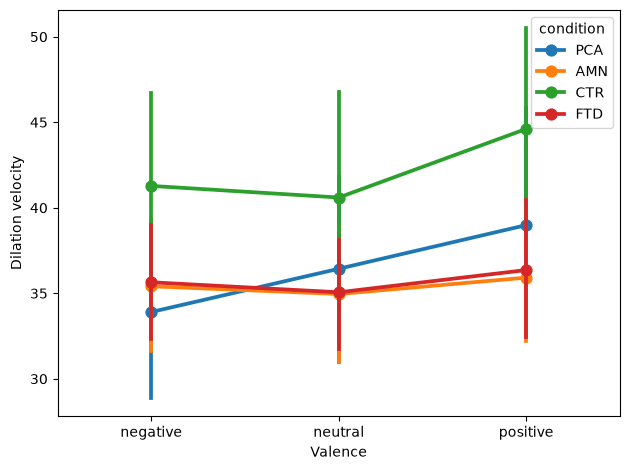

In [116]:
ax = sns.pointplot(df, x='valence', y='RDX_max', hue='condition', errorbar=('ci', 95))
ax.set_xlabel('Valence')
ax.set_ylabel('Dilation velocity')
plt.tight_layout()

In [ ]:
sbs

[Text(0.5, 0, 'Number of patients'),
 Text(0, 0.5, 'Condition'),
 Text(0.5, 1.0, 'Number of patients per condition')]

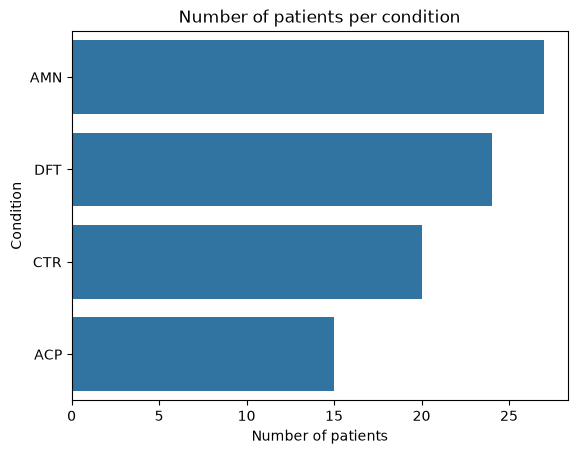

In [11]:
# (df.condition.value_counts()/6).plot.barh()

ax = sns.barplot(data = df.condition.value_counts()/6, orient='h')
ax.set(xlabel='Number of patients', ylabel='Condition', title='Number of patients per condition')

# plt.savefig('figures/analysis/missing_conds.png', dpi=150)

### Rebalancing dataset

In [15]:
X_resampled, y_resampled = SMOTE().fit_resample(X, y)
# X_resampled, y_resampled = ADASYN(sampling_strategy='minority').fit_resample(X, y)

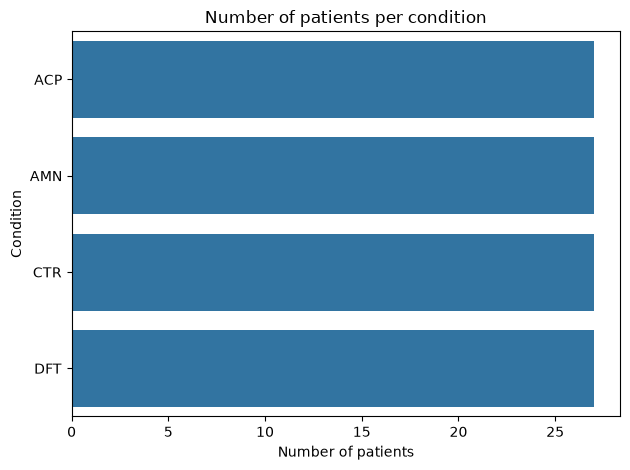

In [16]:
test = pd.concat([X_resampled, y_resampled], axis=1)

ax = sns.barplot(data = test.condition.value_counts()/6, orient='h')
ax.set(xlabel='Number of patients', ylabel='Condition', title='Number of patients per condition')


plt.tight_layout()
# plt.savefig('figures/analysis/SMOTE_rebalancing', dpi=150)

In [20]:
df = df.loc[df['RDX_grad']>0, :]

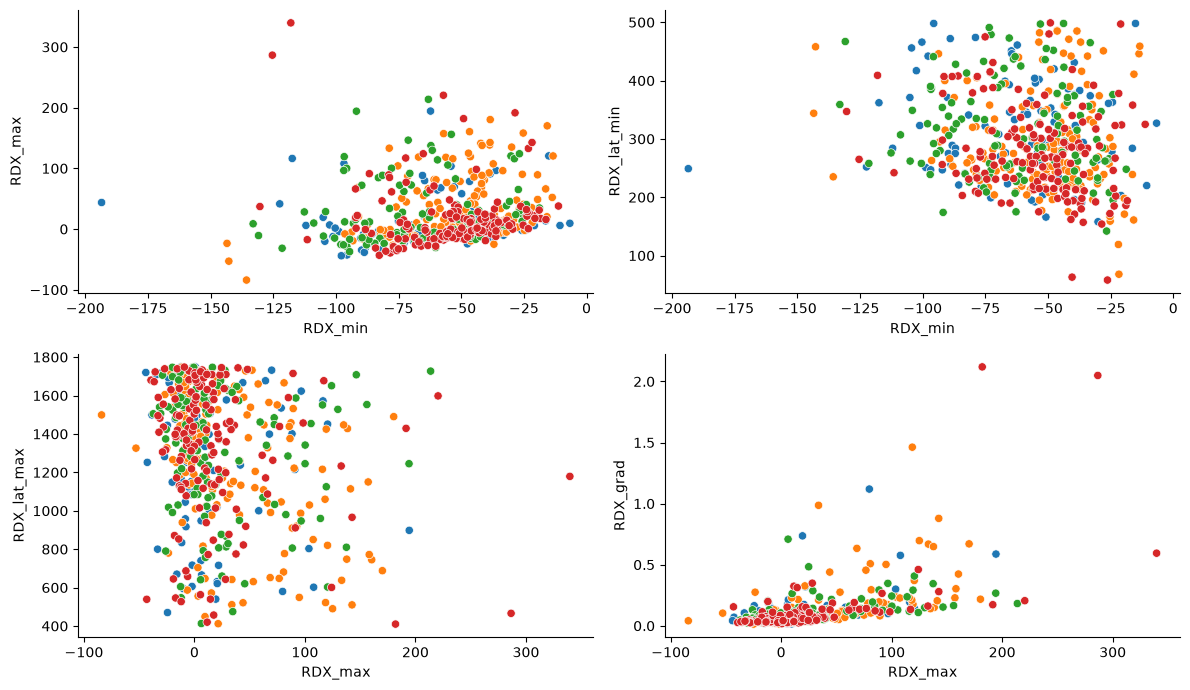

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax = ax.flatten()


sns.scatterplot(df, x='RDX_min', y='RDX_max', ax=ax[0], hue='condition', legend=False)
sns.scatterplot(df, x='RDX_min', y='RDX_lat_min', ax=ax[1], hue='condition', legend=False)

sns.scatterplot(df, x='RDX_max', y='RDX_lat_max', ax=ax[2], hue='condition', legend=False)
sns.scatterplot(df, x='RDX_max', y='RDX_grad', ax=ax[3], hue='condition', legend=False)


for a in ax:
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(False)

plt.tight_layout()

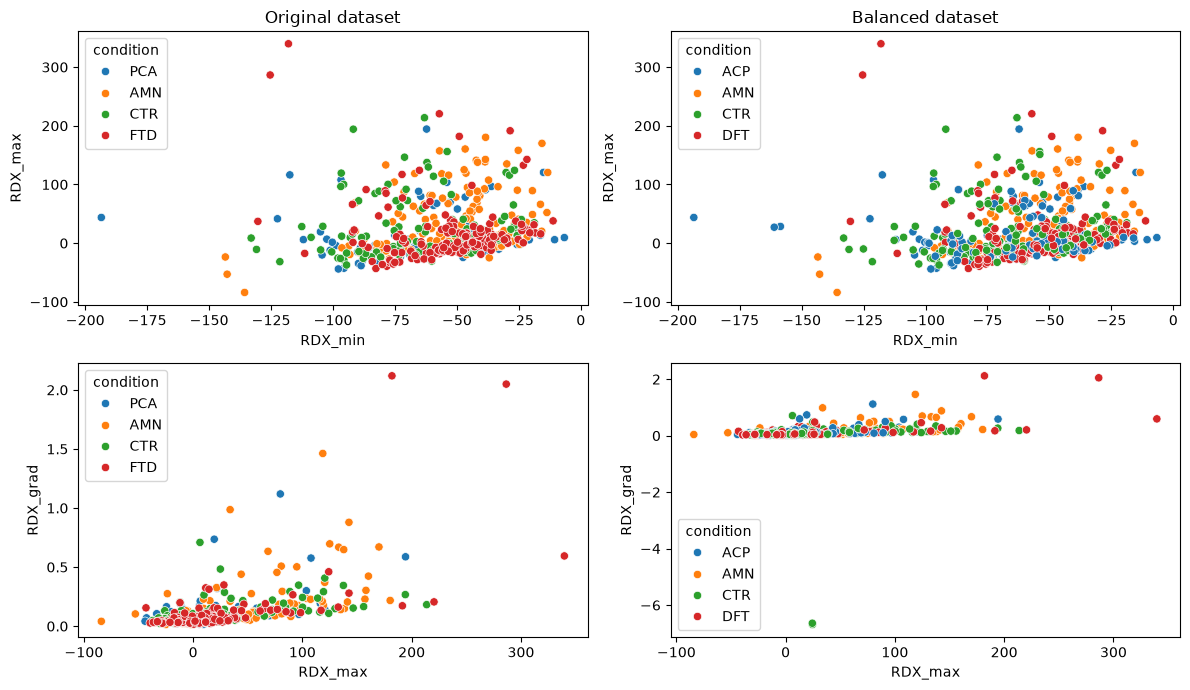

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))


sns.scatterplot(df, x='RDX_min', y='RDX_max', ax=ax[0][0], hue='condition')
sns.scatterplot(df, x='RDX_max', y='RDX_grad', ax=ax[1][0], hue='condition')

sns.scatterplot(test, x='RDX_min', y='RDX_max', ax=ax[0][1], hue='condition')
sns.scatterplot(test, x='RDX_max', y='RDX_grad', ax=ax[1][1], hue='condition')

ax[0][0].set_title('Original dataset')
ax[0][1].set_title('Balanced dataset')

plt.tight_layout()

### Dummy model

In [91]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X, groups=id):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

dummy_clf = DummyClassifier(strategy='uniform', random_state=42)
dummy_clf.fit(X_train, y_train)
y_pred = dummy_clf.predict(X_test)
proba = dummy_clf.predict_proba(X)
score = dummy_clf.score(X, y)

print(classification_report(y_test, y_pred))
print(balanced_accuracy_score(y_test, y_pred, adjusted=True))
f1_score(y_test, y_pred, average='macro')

              precision    recall  f1-score   support

         ACP       0.25      0.21      0.23        24
         AMN       0.16      0.28      0.20        18
         CTR       0.20      0.28      0.23        18
         DFT       0.41      0.27      0.33        48

    accuracy                           0.26       108
   macro avg       0.25      0.26      0.25       108
weighted avg       0.30      0.26      0.27       108

0.011574074074074106


0.24722812486516804

### Reference model

In [92]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X, groups=id):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(X_train, y_train)
y_pred = lr_clf.predict(X_test)

print(classification_report(y_test, y_pred))
print(balanced_accuracy_score(y_test, y_pred, adjusted=True))
f1_score(y_test, y_pred, average='macro')

              precision    recall  f1-score   support

         ACP       0.00      0.00      0.00        24
         AMN       0.19      0.94      0.32        18
         CTR       0.11      0.11      0.11        18
         DFT       0.00      0.00      0.00        48

    accuracy                           0.18       108
   macro avg       0.07      0.26      0.11       108
weighted avg       0.05      0.18      0.07       108

0.018518518518518528


/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arthur/git/2026_M1_inte

0.10721570627231004

In [135]:
from sklearn.preprocessing import quantile_transform


In [11]:
from sklearn.preprocessing import QuantileTransformer

y_trans = QuantileTransformer(
    n_quantiles=500, subsample=500, output_distribution="normal", copy=True, random_state=42
).set_output(transform="pandas")

y_trans = y_trans.fit_transform(X.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad']])

In [12]:
y_trans

,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
0,0.153815,0.679227,-0.277283,0.750579,-0.698331
1,-1.879911,0.833062,0.345845,-1.837526,2.256360
2,-1.194033,0.093065,-1.798207,1.438471,-0.679227
3,-1.749757,0.438088,-0.921646,5.199338,-0.052769
4,-0.179283,0.118323,-0.465906,-0.394263,-0.123383
...,...,...,...,...,...
511,0.454737,0.153815,-0.256461,0.730753,-1.018128
512,0.654133,0.037684,0.477134,2.256360,-0.471513
513,0.277283,-0.238332,0.138583,1.345832,-0.737330
514,0.976822,-0.118323,0.143657,0.872812,-1.052467


In [8]:
i = X.loc[X['RDX_grad']<0, 'RDX_grad'].index

X = X.drop(i)

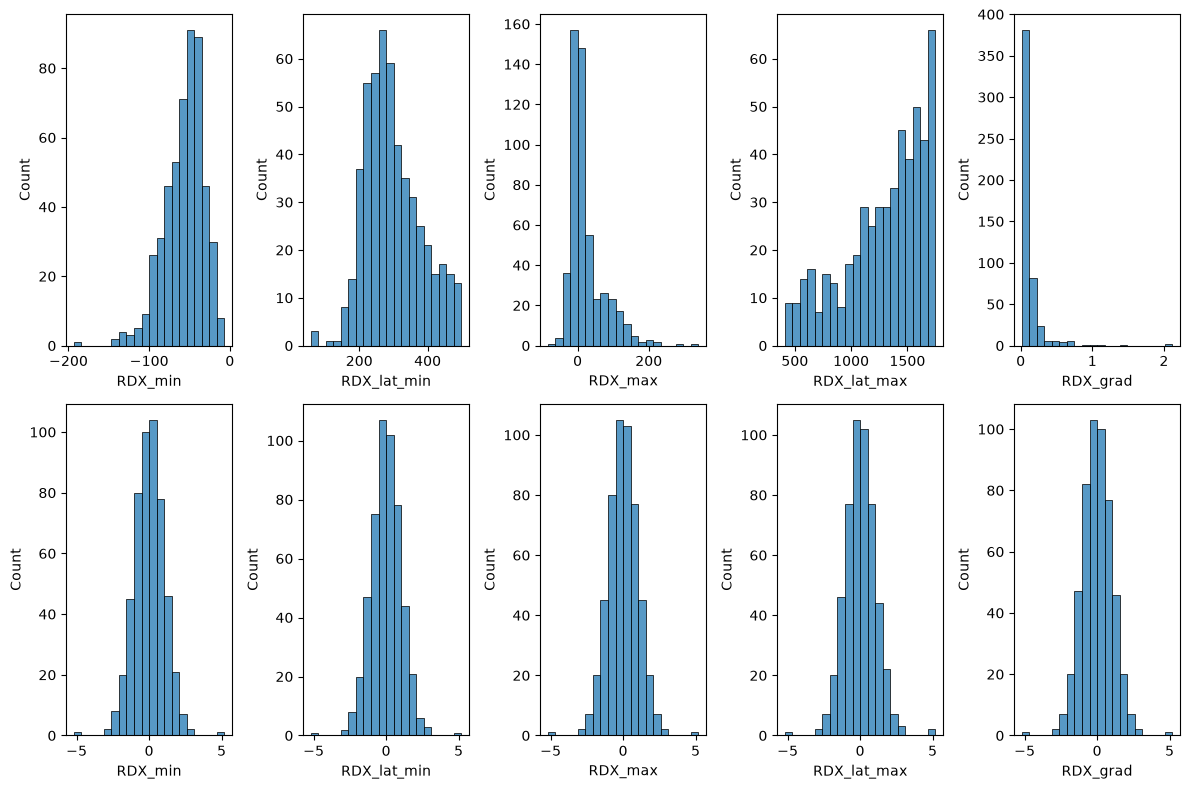

In [14]:
fig, ax = plt.subplots(2, 5, figsize=(12, 8))

sns.histplot(X, x='RDX_min', bins=20, ax=ax[0][0])
sns.histplot(X, x='RDX_lat_min', bins=20, ax=ax[0][1])
sns.histplot(X, x='RDX_max', bins=20, ax=ax[0][2])
sns.histplot(X, x='RDX_lat_max', bins=20, ax=ax[0][3])
sns.histplot(X, x='RDX_grad', bins=20, ax=ax[0][4])

sns.histplot(y_trans, x='RDX_min', bins=20, ax=ax[1][0])
sns.histplot(y_trans, x='RDX_lat_min', bins=20, ax=ax[1][1])
sns.histplot(y_trans, x='RDX_max', bins=20, ax=ax[1][2])
sns.histplot(y_trans, x='RDX_lat_max', bins=20, ax=ax[1][3])
sns.histplot(y_trans, x='RDX_grad', bins=20, ax=ax[1][4])

# ax[0][0].set_title('RDX_min')
# ax[0][1].set_title('RDX_lat_min')
# ax[0][2].set_title('RDX_max')
# ax[0][3].set_title('RDX_lat_max')
# ax[0][4].set_title('RDX_grad')

plt.tight_layout()
plt.savefig('figures/analysis/quantile_transform_comparison.png', dpi=150)

,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
114688,5.199338,0.477134,0.042711,-0.108212,-2.511438


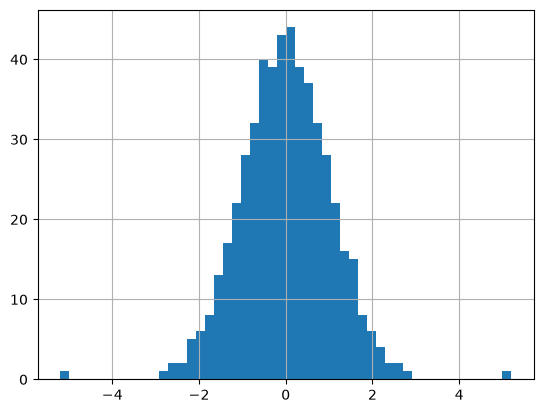

In [49]:
y_trans['RDX_min'].hist(bins=50)
y_trans[y_trans['RDX_min']>4]

### Train, test, split

In [119]:
X.columns

Index(['category', 'valence', 'RDX_min', 'RDX_lat_min', 'RDX_max',
       'RDX_lat_max', 'RDX_max_con_velocity', 'RDX_ave_con_velocity',
       'RDX_max_dil_velocity', 'RDX_ave_dil_velocity', 'category_objet',
       'category_visage', 'valence_negative', 'valence_neutre',
       'valence_positive'],
      dtype='str')

In [6]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, classification_report


## Scaling
# numeric_features = ['D_0', 'D_1', 't_0', 'tau_1', 'tau_2']
# numeric_features = ['RDX_min',      'RDX_lat_min',          'RDX_max',
#       'RDX_lat_max',          'RDY_min',      'RDY_lat_min',
#           'RDY_max',      'RDY_lat_max',         'RDX_grad',
#          'RDY_grad',     'RDX_area_min',     'RDX_area_max']

numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_max',
       'RDX_lat_max', 'RDX_max_con_velocity', 'RDX_ave_con_velocity',
       'RDX_max_dil_velocity', 'RDX_ave_dil_velocity']

categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', RobustScaler())])
# numeric_transformer = Pipeline([('scaler', QuantileTransformer(n_quantiles=200, subsample=200, output_distribution="normal", copy=True, random_state=42))])

categorical_transformer = Pipeline([('passthrough', 'passthrough')])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)), 
    ('clf', SVC(random_state=42))
])

# pipeline = Pipeline(
#     [
#         ("preprocessor", preprocessor),
#         ('clf', SVC(random_state=42))
# ])

param_grid = [
    {
        'clf' : [SVC(random_state=42)],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01],
        'clf__kernel': ['linear', 'rbf', 'poly'],
        'clf__degree': [2, 3, 4]

    },
    {
        'clf' : [RandomForestClassifier(random_state=42)],
        'clf__n_estimators': [1, 10, 50, 100],
        'clf__criterion': ['gini', 'entropy', 'log_loss'],
        'clf__max_depth': [5, 20, 50, 100],
        'clf__min_samples_split': [2, 5, 8, 10]
    },
    {
        'clf' : [LogisticRegression(random_state=42)],
        'clf__C': [0.01, 0.1, 0.5, 1.0, 1.5, np.inf],
        'clf__l1_ratio': [0, 0.5, 1],
        'clf__solver': ['lbfgs', 'newton-cholesky', 'sag', 'saga'],
        'clf__max_iter': [50, 200, 500, 1000]
    },
    {
        'clf' : [GradientBoostingClassifier(random_state=42)],
        'clf__loss': ['log_loss'],
        'clf__learning_rate': [0.01, 0.1, 1],
        'clf__n_estimators': [1, 100, 1000],
        'clf__min_samples_split': [2, 4, 6],
        'clf__max_depth': [1, 3, 5]
    },
    {
        'clf' : [KNeighborsClassifier()],
        'clf__n_neighbors': [1, 2, 3, 5],
        'clf__weights': ['uniform', 'distance'],
        'clf__algorithm': ['ball_tree', 'kd_tree', 'brute'],
        'clf__p': [1, 2]
    },
    {
        'clf' : [AdaBoostClassifier(random_state=42)],
        'clf__n_estimators': [20, 50, 100],
        'clf__learning_rate': [0.01, 0.1, 1]
    }
]

## Store variables
results = {
    'accuracy': [],
    'proba': [],
    'f1_score': [],
    'balanced_accuracy': [],
    'classification_report': [],
    'best_params': [],
    'best_model': [],
    'train_cond_distribution': [],
    'test_cond_distribution': [],
    'confusion_matrices': [],
    'train_idx_folds': [],
    'X_train_folds': [],
    'y_train_folds': []
}

## Optimise model using GridSearchCV
outer_cv = StratifiedGroupKFold(n_splits=5)
inner_cv = StratifiedGroupKFold(n_splits=5)

for train_idx, test_idx in outer_cv.split(X, y, groups=id):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    id_train, id_test = id.iloc[train_idx], id.iloc[test_idx]

    gridsearch = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1_macro', cv=inner_cv, n_jobs=-1)
    gridsearch.fit(X_train, y_train, groups=id_train)

    best_params = gridsearch.best_params_
    best_model = gridsearch.best_estimator_

    y_pred = best_model.predict(X_test)
    # proba = best_model.predict_proba(X_test)

    score = best_model.score(X_test, y_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    results['accuracy'].append(score)
    # results['proba'].append(proba)
    results['f1_score'].append(f1_macro)
    results['balanced_accuracy'].append(balanced_accuracy_score(y_test, y_pred, adjusted=True))
    results['classification_report'].append(classification_report(y_test, y_pred))

    results['best_params'].append(best_params)
    results['best_model'].append(best_model)
    results['train_idx_folds'].append(train_idx)
    results['X_train_folds'].append(X_train)
    results['y_train_folds'].append(y_train)

    results['train_cond_distribution'].append(y_train.value_counts()/6)
    results['test_cond_distribution'].append(y_test.value_counts()/6)

    cm = confusion_matrix(y_test, y_pred)
    results['confusion_matrices'].append(cm)


ValueError: 
All the 4215 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4215 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_params, raw_params=params)
             ~~~~~~~~~^^^^^^^^^^^^^^^^^^^

In [ ]:
results = joblib.dump(results, 'results/fitted_B_QT.pkl')
# results.keys()

AttributeError: 'list' object has no attribute 'keys'

In [26]:
print(results['balanced_accuracy'])
results['f1_score']

[-0.040740740740740744, -0.11018518518518516, 0.06481481481481481, 0.0, -0.04259259259259259]


[0.22037037037037036,
 0.16790074684425382,
 0.28333233735221874,
 0.2589536479780382,
 0.20413980776810892]

In [27]:
results['best_params']

[{'clf': GradientBoostingClassifier(random_state=42),
  'clf__learning_rate': 1,
  'clf__loss': 'log_loss',
  'clf__max_depth': 3,
  'clf__min_samples_split': 2,
  'clf__n_estimators': 1000},
 {'clf': KNeighborsClassifier(),
  'clf__algorithm': 'ball_tree',
  'clf__n_neighbors': 5,
  'clf__p': 2,
  'clf__weights': 'distance'},
 {'clf': KNeighborsClassifier(),
  'clf__algorithm': 'ball_tree',
  'clf__n_neighbors': 3,
  'clf__p': 1,
  'clf__weights': 'uniform'},
 {'clf': GradientBoostingClassifier(random_state=42),
  'clf__learning_rate': 0.01,
  'clf__loss': 'log_loss',
  'clf__max_depth': 5,
  'clf__min_samples_split': 2,
  'clf__n_estimators': 1},
 {'clf': RandomForestClassifier(random_state=42),
  'clf__criterion': 'entropy',
  'clf__max_depth': 20,
  'clf__min_samples_split': 8,
  'clf__n_estimators': 10}]

In [28]:
print(results['classification_report'][2])

              precision    recall  f1-score   support

         ACP       0.28      0.44      0.34        18
         AMN       0.32      0.33      0.33        30
         CTR       0.30      0.25      0.27        24
         DFT       0.23      0.17      0.19        30

    accuracy                           0.28       102
   macro avg       0.28      0.30      0.28       102
weighted avg       0.28      0.28      0.28       102



#### Save best models

In [5]:
from sklearn.model_selection import GroupShuffleSplit

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer


from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, classification_report

import joblib


gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X, groups=id):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]


numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_lat_max', 'RDX_max', 'RDX_grad']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', RobustScaler())])
# numeric_transformer = Pipeline([('scaler', QuantileTransformer(n_quantiles=500, subsample=500, output_distribution="normal", copy=True, random_state=42))])

categorical_transformer = Pipeline([('passthrough', 'passthrough')])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
) 

pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)), 
    ('clf', LogisticRegression(random_state=42, C=np.inf, l1_ratio=0, max_iter=500, solver='lbfgs'))
])



clf = pipeline.fit(X_train, y_train)

# joblib.dump(clf, 'lr_best_model.pkl')

['lr_best_model.pkl']

### Learning curves

0


/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/arthur/git/2026_M1

1


/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/arthur/git/2026_M1

2
3


/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/arthur/git/2026_M1_

4


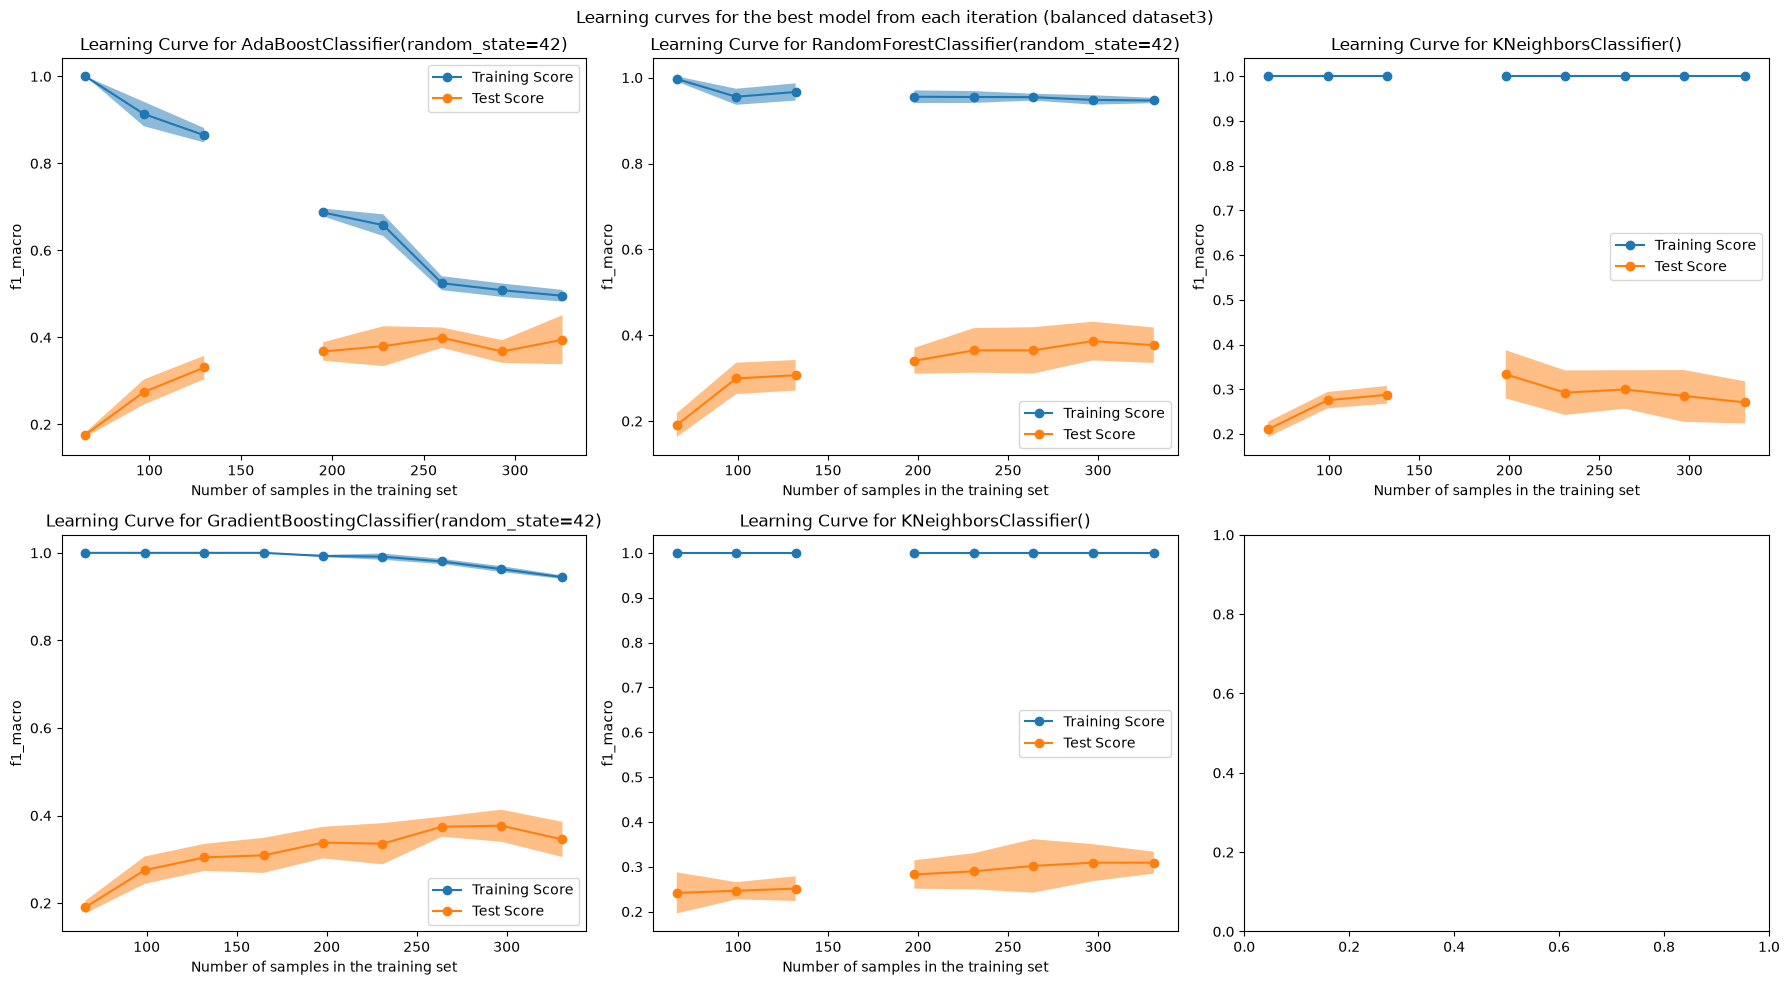

In [25]:
from sklearn.model_selection import learning_curve, StratifiedKFold, LearningCurveDisplay

fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.flatten()

train_sizes = np.linspace(0.1, 1.0, 10)
cv_for_learning = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for ax_idx, fold_idx in enumerate(results['best_model']):
    print(ax_idx)
    X_train = results['X_train_folds'][ax_idx]
    y_train = results['y_train_folds'][ax_idx]
    estimator = results['best_model'][ax_idx]

    common_params = {
        "X": X_train,
        "y": y_train,
        "train_sizes": train_sizes,
        "cv": cv_for_learning,
        "score_type": "both",
        "n_jobs": -1,
        "line_kw": {"marker": "o"},
        "std_display_style": "fill_between",
        "score_name": "f1_macro",
    }

    LearningCurveDisplay.from_estimator(estimator, **common_params, ax=ax[ax_idx])
    handles, label = ax[ax_idx].get_legend_handles_labels()
    ax[ax_idx].legend(handles[:2], ["Training Score", "Test Score"])
    ax[ax_idx].set_title(f"Learning Curve for {results['best_params'][ax_idx]['clf']}")


fig.suptitle('Learning curves for the best model from each iteration (balanced dataset3)')
plt.tight_layout()
plt.savefig('figures/dataset3_balanced_learningcurve.png', dpi=150)

### Optuna test

In [ ]:
import optuna

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['SVC', 'RandomForest'])
    if classifier_name == 'SVC':
        svc_c = trial.suggest_float('svc_c', 1e-10, 1e10, log=True)
        classifier_obj = SVC(C=svc_c, gamma='auto')
    else:
        rf_max_depth = trial.suggest_int('rf_max_depth', 2, 32, log=True)
        classifier_obj = RandomForestClassifier(max_depth=rf_max_depth, n_estimators=10)

    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(f'BEST: {study.best_params}')





# svm = SVC()

# p_grid = {"C": [1, 10, 100], "gamma": [0.01, 0.1], "kernel": {'linear', 'poly', 'rbf'}}

# outer_cv = GroupKFold(n_splits=3)
# inner_cv = GroupKFold(n_splits=5)

# scores = []

# for train_idx, test_idx in outer_cv.split(X, y, groups=id):
#     X_train_outer, X_test_outer = X[train_idx], X[test_idx]
#     y_train_outer, y_test_outer = y[train_idx], y[test_idx]

#     clf = GridSearchCV(estimator=svm, param_grid=p_grid, cv=inner_cv)
#     clf.fit(X_train_outer, X_train_outer)
#     scores.append(clf.best_score_)



[I 2026-09-03 19:21:54,100] A new study created in memory with name: no-name-ba5438a9-583c-4301-a983-243161536d01
[I 2026-09-03 19:21:54,102] Trial 0 finished with value: 0.28888888888888886 and parameters: {'classifier': 'SVC', 'svc_c': 1.5348130218959242e-09}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,102] Trial 1 finished with value: 0.28888888888888886 and parameters: {'classifier': 'RandomForest', 'rf_max_depth': 2}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,103] Trial 2 finished with value: 0.28888888888888886 and parameters: {'classifier': 'SVC', 'svc_c': 1.2253276580020046e-09}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,104] Trial 3 finished with value: 0.28888888888888886 and parameters: {'classifier': 'RandomForest', 'rf_max_depth': 8}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,104] Trial 4 finished with value: 0.28888888888888886 and parameters: {'classifie

BEST: {'classifier': 'SVC', 'svc_c': 1.5348130218959242e-09}


#### TEST
- transformer: preprocessing
- estimator: model

##### Breakdown
- Step 1: test different base models (SVM, RandomForest, LogisticRegression, XGboost) -> use a DummyClassifier as reference to chance
- Step 2: choose the best model and optimise it

Figure out a clear modelling pipeline